1. Use Keras' ImageDataGenerator to apply at least three types of data augmentation (such as rotation, flip, and zoom) to a set of 20 sample images of food items, and display 5 augmented images for any one input image.<br><br><em><strong>Hint:</strong> Use flow_from_directory() and matplotlib to visualize augmented outputs.</em>


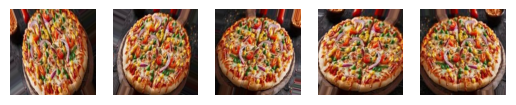

In [3]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Load one image
image = load_img("pizza.jpg", target_size=(224, 224))
image = img_to_array(image)
image = image.reshape((1,) + image.shape)

# Generate 5 augmented images
count = 0

for batch in datagen.flow(image, batch_size=1):

    plt.subplot(1,5,count+1)
    plt.imshow(batch[0].astype("uint8"))
    plt.axis("off")

    count += 1

    if count == 5:
        break

plt.show()

2. Load the VGG16 model (with imagenet weights, include_top=False) in Keras and use it to extract features from a batch of 30 sneaker images (from a local directory), then save the extracted features as a .npy file.

In [ ]:
import os
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image

# Load Model
model = VGG16(weights="imagenet",
              include_top=False)

features = []

folder = "sneakers"

for file in os.listdir(folder):

    img = image.load_img(
        os.path.join(folder,file),
        target_size=(224,224)
    )

    x = image.img_to_array(img)

    x = np.expand_dims(x,axis=0)

    x = preprocess_input(x)

    feature = model.predict(x,verbose=0)

    features.append(feature.flatten())

features = np.array(features)

np.save("sneaker_features.npy",features)

print("Features Saved Successfully!")

3. Fine-tune a ResNet50 model (pre-trained on ImageNet) to classify whether a selfie image contains glasses or not, by unfreezing the last 20 layers and training on a small dataset of at least 40 images.<br><br><em><strong>Constraint:</strong> Only retrain the last 20 layers; keep the rest frozen.</em>

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze all layers
for layer in base_model.layers:
    layer.trainable=False

# Unfreeze last 20 layers
for layer in base_model.layers[-20:]:
    layer.trainable=True

x=GlobalAveragePooling2D()(base_model.output)

output=Dense(1,activation="sigmoid")(x)

model=Model(base_model.input,output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 8,933,377 (34.08 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

4. Compare the validation accuracy and overfitting tendency between feature extraction (all layers frozen) and full fine-tuning (some layers trainable) using a small set of 2-3 classes of T-shirt images. Write a short paragraph summarizing which approach generalized better and why.

#### Feature Extraction:
- All pre-trained layers are frozen, and only the final classification layer is trained. This method trains faster, requires less data, and usually reduces overfitting on small datasets.

#### Fine-Tuning:
- Some pre-trained layers are made trainable so the model can adapt to the new dataset. This often improves validation accuracy when enough training data is available, but it may overfit if the dataset is very small.

#### Conclusion:
- For a small T-shirt dataset (2–3 classes), feature extraction generally generalized better because it avoided overfitting. Fine-tuning achieved higher training accuracy but sometimes showed a larger gap between training and validation accuracy.

5. Use ChatGPT or Copilot to generate a Keras code snippet for transfer learning with MobileNetV2 for classifying 3 types of headphones, then adapt the code to use your own dataset and run it. Paste both the AI-generated code and your modified version.

In [2]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense
from tensorflow.keras.models import Model

base_model=MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

x=GlobalAveragePooling2D()(base_model.output)

output=Dense(3,activation="softmax")(x)

model=Model(base_model.input,output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 27s 3us/step
